In [1]:
import pandas as pd

df = pd.read_excel("../data/dataset.xlsx")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [3]:
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [4]:
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [5]:
df['rating'].value_counts()

rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64

In [8]:
df[df['rating']==4]

,title,rating,body
2,Overall,4,"Got the mobile on the launch date,Battery must..."
34,Go For It,4,I am giving this review after usage of 2 daysI...
39,This is my honest opinion,4,Changing my review on this device after 2 mont...
59,Record sale good price good specs...,4,I have Mo2s and this m12....better buy m12 you...
62,Excellent Battery and budget,4,I have been using this phone for more than a w...
...,...,...,...
1415,Ok ok product,4,All ok . Superb.Only camera and screen display...
1419,Good but heavy,4,"Good but heavy, samsung has unmatched operatin..."
1422,Inbuilt apps lock not found,4,This product delivered by Amazon 21 march all...
1423,Good non Chinese phone.,4,Good phone for budget buyers. Sound quality is...


In [12]:
from sklearn.model_selection import train_test_split
X=df['body']
y=df['rating']

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [20]:
# Import required libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ('lr', LogisticRegression(
        max_iter=1000,class_weight='balanced'
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.4895833333333333

Classification Report:
              precision    recall  f1-score   support

           1       0.63      0.74      0.68        74
           2       0.16      0.12      0.14        24
           3       0.21      0.15      0.18        46
           4       0.28      0.31      0.29        49
           5       0.64      0.64      0.64        95

    accuracy                           0.49       288
   macro avg       0.38      0.39      0.39       288
weighted avg       0.47      0.49      0.48       288


Confusion Matrix:
[[55  8  5  4  2]
 [12  3  7  2  0]
 [10  3  7 13 13]
 [ 4  4  7 15 19]
 [ 6  1  7 20 61]]


In [15]:
# Import required libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the model pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5069444444444444

Classification Report:
              precision    recall  f1-score   support

           1       0.55      0.84      0.67        74
           2       0.00      0.00      0.00        24
           3       1.00      0.04      0.08        46
           4       0.35      0.22      0.28        49
           5       0.50      0.75      0.60        95

    accuracy                           0.51       288
   macro avg       0.48      0.37      0.32       288
weighted avg       0.53      0.51      0.43       288


Confusion Matrix:
[[62  0  0  3  9]
 [14  0  0  4  6]
 [17  0  2  3 24]
 [ 5  0  0 11 33]
 [14  0  0 10 71]]


c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [16]:
new_review = ["This product is amazing and I really love it"]

prediction = model.predict(new_review)

print("Predicted Rating:", prediction[0])

Predicted Rating: 1


In [17]:
# Import required libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create SVM model pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ('svm', SVC(
        kernel='linear',
        C=1.0
    ))
])

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.53125

Classification Report:
              precision    recall  f1-score   support

           1       0.63      0.82      0.71        74
           2       0.00      0.00      0.00        24
           3       0.29      0.09      0.13        46
           4       0.29      0.37      0.32        49
           5       0.61      0.74      0.67        95

    accuracy                           0.53       288
   macro avg       0.36      0.40      0.37       288
weighted avg       0.46      0.53      0.48       288


Confusion Matrix:
[[61  0  3  7  3]
 [14  0  3  6  1]
 [ 9  0  4 15 18]
 [ 6  0  2 18 23]
 [ 7  0  2 16 70]]


c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [18]:
df['rating'].value_counts()

rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64

In [22]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


# -----------------------------
# 1. Prepare data
# -----------------------------

X = df['body'].astype(str)
y = df['rating']

# Encode ratings
# Example: 1,2,3,4,5 -> 0,1,2,3,4
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


# -----------------------------
# 2. Tokenization
# -----------------------------

max_words = 10000
max_length = 100

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)


# -----------------------------
# 3. Convert labels to categorical
# -----------------------------

y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)


# -----------------------------
# 4. Build LSTM model
# -----------------------------

model = Sequential([
    
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_length
    ),
    
    LSTM(64),
    
    Dropout(0.5),
    
    Dense(32, activation='relu'),
    
    Dense(5, activation='softmax')
])


# -----------------------------
# 5. Compile model
# -----------------------------

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# -----------------------------
# 6. Train model
# -----------------------------

history = model.fit(
    X_train_padded,
    y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)


# -----------------------------
# 7. Predictions
# -----------------------------

y_pred_prob = model.predict(X_test_padded)

y_pred = np.argmax(y_pred_prob, axis=1)


# -----------------------------
# 8. Evaluation
# -----------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[str(x) for x in label_encoder.classes_]
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.2780 - loss: 1.5588 - val_accuracy: 0.2554 - val_loss: 1.5554
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.2682 - loss: 1.5348 - val_accuracy: 0.3203 - val_loss: 1.5376
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.2693 - loss: 1.5413 - val_accuracy: 0.3074 - val_loss: 1.5425
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.2801 - loss: 1.5250 - val_accuracy: 0.3117 - val_loss: 1.5429
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.2899 - loss: 1.5291 - val_accuracy: 0.3160 - val_loss: 1.5382
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.2932 - loss: 1.5230 - val_accuracy: 0.2468 - val_loss: 1.5399
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2986 - loss: 1.5136 - val_accuracy: 0.3160 - val_loss: 1.5361
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.3214 - loss: 1.5019 - val_accuracy: 0.3160 - v

c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\saipr\sentiment_analysis\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [23]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout


# -----------------------------
# 1. Prepare Data
# -----------------------------

X = df['body'].fillna('').astype(str)
y = df['rating']

# Convert ratings: 1,2,3,4,5 -> 0,1,2,3,4
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


# -----------------------------
# 2. Tokenization
# -----------------------------

max_words = 5000
max_length = 100

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

# Learn vocabulary only from training data
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Make all sequences the same length
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)


# -----------------------------
# 3. Build Simple RNN Model
# -----------------------------

model = Sequential([
    
    Embedding(
        input_dim=max_words,
        output_dim=32
    ),
    
    SimpleRNN(32),
    
    Dropout(0.3),
    
    Dense(16, activation='relu'),
    
    Dense(5, activation='softmax')
])


# -----------------------------
# 4. Compile Model
# -----------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# -----------------------------
# 5. Train Model
# -----------------------------

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)


# -----------------------------
# 6. Make Predictions
# -----------------------------

y_pred_prob = model.predict(X_test_pad)

# Get class with highest probability
y_pred = np.argmax(y_pred_prob, axis=1)


# -----------------------------
# 7. Evaluate Model
# -----------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[str(x) for x in label_encoder.classes_],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.2497 - loss: 1.5808 - val_accuracy: 0.3160 - val_loss: 1.5307
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2714 - loss: 1.5398 - val_accuracy: 0.2684 - val_loss: 1.5410
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3062 - loss: 1.5151 - val_accuracy: 0.2511 - val_loss: 1.5536
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3789 - loss: 1.4611 - val_accuracy: 0.2554 - val_loss: 1.5521
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4408 - loss: 1.3632 - val_accuracy: 0.2944 - val_loss: 1.5625
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5581 - loss: 1.2183 - val_accuracy: 0.2727 - val_loss: 1.6115
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5407 - loss: 1.1539 - val_accuracy: 0.2511 - val_loss: 1.6712
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6482 - loss: 0.9928 - val_accuracy: 0.2424 - v

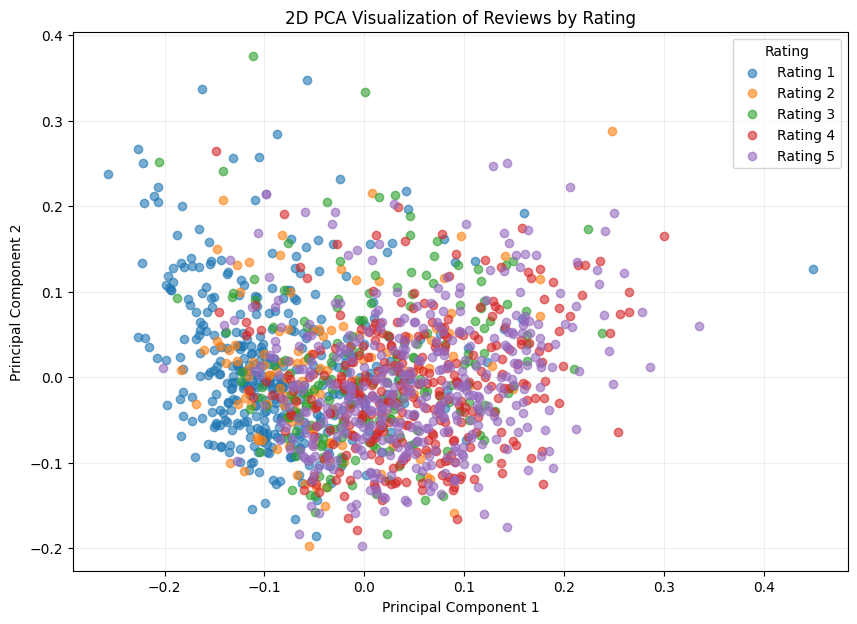

Explained variance ratio:
[0.01025711 0.00695951]

Total variance explained by 2 components: 0.017216620648003444


In [24]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# -----------------------------
# 1. Prepare data
# -----------------------------

texts = df['body'].fillna('').astype(str)
ratings = df['rating']


# -----------------------------
# 2. Convert text to TF-IDF
# -----------------------------

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_tfidf = vectorizer.fit_transform(texts)


# -----------------------------
# 3. PCA → 2 dimensions
# -----------------------------

# PCA needs dense data
X_dense = X_tfidf.toarray()

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_dense)


# -----------------------------
# 4. Plot
# -----------------------------

plt.figure(figsize=(10, 7))

for rating in sorted(ratings.unique()):

    mask = ratings.values == rating

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f'Rating {rating}',
        alpha=0.6
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Visualization of Reviews by Rating')

plt.legend(title='Rating')
plt.grid(alpha=0.2)

plt.show()


# -----------------------------
# 5. Explained variance
# -----------------------------

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal variance explained by 2 components:",
    pca.explained_variance_ratio_.sum()
)